In [30]:
import sys

sys.path.append('..')

### Пример

$y= \sqrt{𝑥 + 1} − \sqrt{𝑥^2 + 19𝑥 + 123} $   где 𝑥 ∈ [0, 2]

# Численное дифференцирование

##### Нахождение $f'(x)$ методом конечных разностей

In [31]:
import numpy as np
from math import log

def f(x): return np.sqrt(𝑥 + 1) - np.sqrt(x**2 + 19*x +123) 


dx = [0.2, 0.02, 0.002]

x = [np.arange(0, 2 + d / 2, d) for d in dx]
y = [np.array([f(s) for s in t]) for t in x] 

df_fd = [np.zeros(len(t)) for t in x]

for i in range(len(x)):
    n = len(x[i])

    for j in range(1, n-1):
        df_fd[i][j] = (y[i][j+1] - y[i][j-1])/2/dx[i]

    df_fd[i][0] = (-3*y[i][0] + 4*y[i][1] - y[i][2])/2/dx[i]
    df_fd[i][n-1] = (y[i][n-3] - 4*y[i][n-2] + 3*y[i][n-1])/2/dx[i]

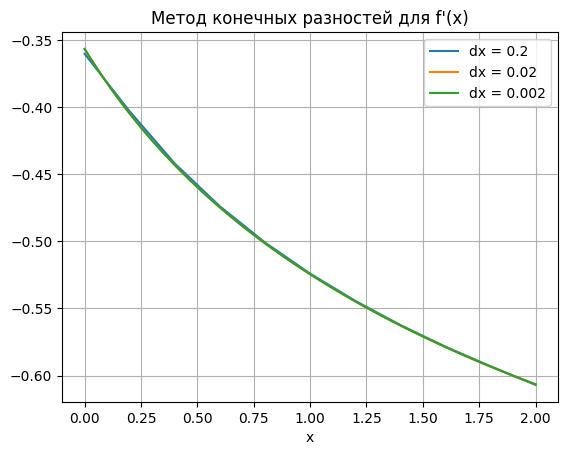

In [32]:
from matplotlib import pyplot as plt

for i in range(len(dx)):
    plt.plot(x[i], df_fd[i], label=f'dx = {dx[i]}')

plt.title("Метод конечных разностей для f'(x)")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Нахождение $f'(x)$ используя кубический сплайн

In [33]:
from modules.interpolation.cubic_spline import curvatures

df_cs = [np.zeros(len(t)) for t in x]

k = [curvatures(t, s) for t, s in zip(x, y)]

for i in range(len(x)):
    n = len(x[i])

    for j in range(1, n-1):
        df_cs[i][j] = -k[i][j-1]*(x[i][j] - x[i][j+1])/6 \
                    - k[i][j]*(x[i][j] - x[i][j+1])/3 \
                    + (y[i][j] - y[i][j+1])/(x[i][j] - x[i][j+1])
        
    df_cs[i][0] = k[i][0]*(x[i][0] - x[i][1])/3 \
                + k[i][1]*(x[i][0] - x[i][1])/6 \
                + (y[i][0] - y[i][1])/(x[i][0] - x[i][1])
    
    df_cs[i][n - 1] = -k[i][n-2]*(x[i][n-2] - x[i][n-1])/6 \
                - k[i][n-1]*(x[i][n-2] - x[i][n-1])/3 \
                + (y[i][n-2] - y[i][n-1])/(x[i][n-2] - x[i][n-1])

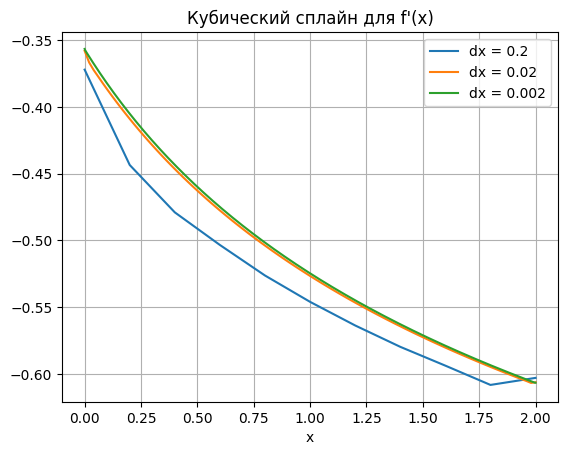

In [34]:
from matplotlib import pyplot as plt

for i in range(len(dx)):
    plt.plot(x[i], df_cs[i], label=f'dx = {dx[i]}')

plt.title("Кубический сплайн для f'(x)")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Нахождение $f''(x)$ методом конечных разностей

In [35]:
df2_fd = [np.zeros(len(t)) for t in x]

for i in range(len(x)):
    n = len(x[i])

    for j in range(1, n-1):
        df2_fd[i][j] = (y[i][j+1] - 2*y[i][j] + y[i][j-1])/dx[i]/dx[i]

    df2_fd[i][0] = (2*y[i][0] - 5*y[i][1] + 4*y[i][2] - y[i][3])/dx[i]/dx[i]
    df2_fd[i][n-1] = (-y[i][n-4] + 4*y[i][n-3] - 5*y[i][n-2] + 2*y[i][n-1])/dx[i]/dx[i]

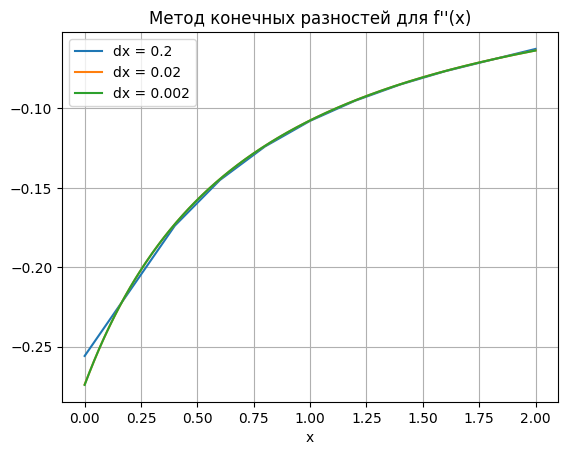

In [36]:
from matplotlib import pyplot as plt

for i in range(len(dx)):
    plt.plot(x[i], df2_fd[i], label=f'dx = {dx[i]}')

plt.title("Метод конечных разностей для f''(x)")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Нахождение $f''(x)$ используя кубический сплайн

In [37]:
df2_cs = k

for i in range(len(x)):
    n = len(x[i])

    df2_cs[i][0] = (df2_cs[i][1] + df2_cs[i][2])/2
    df2_cs[i][n-1] = (df2_cs[i][n-2] + df2_cs[i][n-3])/2

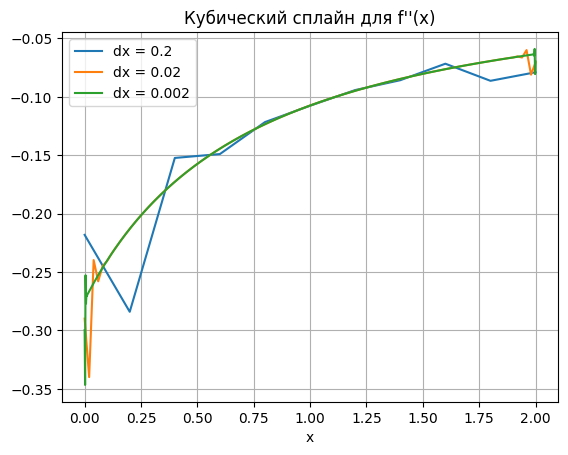

In [38]:
for i in range(len(dx)):
    plt.plot(x[i], df2_cs[i], label=f'dx = {dx[i]}')

plt.title("Кубический сплайн для f''(x)")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Сравнение $f'(x)$ для $dx = 0.1$

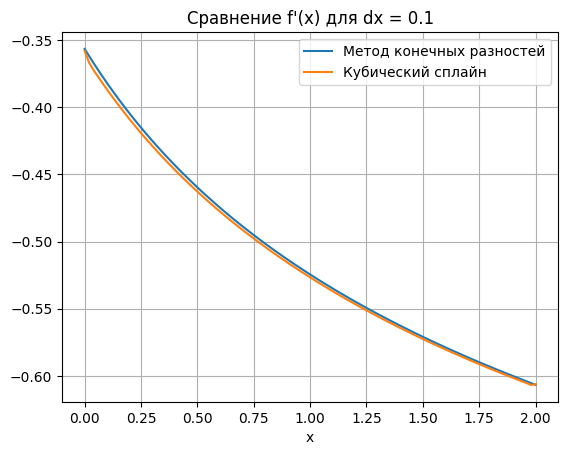

In [39]:
plt.plot(x[1], df_fd[1], label=f'Метод конечных разностей')
plt.plot(x[1], df_cs[1], label=f'Кубический сплайн')

plt.title("Сравнение f'(x) для dx = 0.1")
plt.xlabel('x')
plt.grid()
plt.legend()

##### Сравнение $f''(x)$ для $dx = 0.1$

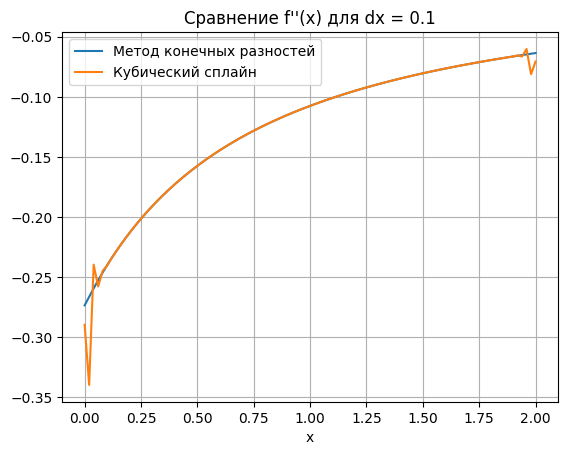

In [40]:
plt.plot(x[1], df2_fd[1], label=f'Метод конечных разностей')
plt.plot(x[1], df2_cs[1], label=f'Кубический сплайн')

plt.title("Сравнение f''(x) для dx = 0.1")
plt.xlabel('x')
plt.grid()
plt.legend()